In [13]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # "Programming Part" auf sys.path

from env import gymnasium_env as drausp_env
import numpy as np

from env.instance_reader import get_instance_data
import matplotlib.pyplot as plt

data_path = Path("../../instances/lion18s/SB03.txt")    

In [14]:
DRAUSP_data = get_instance_data(data_path)

K = DRAUSP_data.num_slots
T_d = 50  # Anzahl Anfragen pro Episode; entspricht Instanz "WC4" (K=12, |N|=1000, C=10, T_d=10) aus Tabelle 1 des Papers, Z*=1.53
C_k = DRAUSP_data.capacity_vector
instance = DRAUSP_data.instance
request_lengths = DRAUSP_data.request_length
pool_size = DRAUSP_data.pool_size
print(f"Number of slots (K): {K}")
print(f"Number of requests per episode (T_d): {T_d}")
print(f"Pool size (|N|): {pool_size}")
print(f"Capacity vector (C_k): {C_k}")
print(f"Instance: {instance}")

Number of slots (K): 8
Number of requests per episode (T_d): 50
Pool size (|N|): 50
Capacity vector (C_k): [10, 10, 10, 10, 10, 10, 10, 10]
Instance: [[41, 1, 1, 2, 1, 0, 0, 0, 0], [39, 2, 1, 2, 1, 0, 0, 0, 0], [20, 3, 1, 1, 2, 0, 0, 0, 0], [61, 1, 2, 1, 1, 0, 0, 0, 0], [18, 1, 1, 1, 3, 0, 0, 0, 0], [23, 1, 1, 1, 1, 0, 0, 0, 0], [25, 3, 3, 1, 1, 0, 0, 0, 0], [13, 2, 1, 2, 2, 0, 0, 0, 0], [77, 1, 1, 1, 1, 0, 0, 0, 0], [8, 2, 1, 1, 1, 0, 0, 0, 0], [25, 2, 2, 1, 1, 0, 0, 0, 0], [74, 1, 1, 1, 1, 0, 0, 0, 0], [39, 1, 1, 1, 2, 0, 0, 0, 0], [54, 1, 1, 2, 1, 0, 0, 0, 0], [70, 1, 1, 1, 1, 0, 0, 0, 0], [71, 1, 1, 1, 1, 0, 0, 0, 0], [55, 1, 2, 1, 3, 0, 0, 0, 0], [9, 3, 2, 2, 1, 0, 0, 0, 0], [96, 1, 1, 1, 1, 0, 0, 0, 0], [63, 3, 1, 2, 1, 0, 0, 0, 0], [50, 1, 1, 1, 1, 0, 0, 0, 0], [20, 2, 1, 2, 2, 0, 0, 0, 0], [43, 1, 1, 1, 1, 0, 0, 0, 0], [74, 1, 2, 1, 4, 0, 0, 0, 0], [62, 1, 1, 2, 1, 0, 0, 0, 0], [60, 1, 1, 1, 1, 0, 0, 0, 0], [22, 1, 2, 3, 1, 0, 0, 0, 0], [81, 2, 1, 1, 1, 0, 0, 0, 0], [92, 1, 1, 

In [15]:
env = drausp_env.DrauspEnv(K=K, T_d=T_d, C_k=C_k, instance=instance, render_mode="human", fixed_request_length=request_lengths)
env.reset(show_instance = True)

Geladene Instanz:
  Anfrage 1: [8, 1, 3, 1, 1, 0, 0, 0, 0]
  Anfrage 2: [13, 2, 1, 2, 2, 0, 0, 0, 0]
  Anfrage 3: [60, 1, 1, 1, 1, 0, 0, 0, 0]
  Anfrage 4: [74, 1, 2, 1, 4, 0, 0, 0, 0]
  Anfrage 5: [84, 1, 3, 1, 1, 0, 0, 0, 0]
  Anfrage 6: [88, 1, 1, 2, 1, 0, 0, 0, 0]
  Anfrage 7: [43, 1, 1, 1, 1, 0, 0, 0, 0]
  Anfrage 8: [20, 2, 1, 2, 2, 0, 0, 0, 0]
  Anfrage 9: [74, 1, 1, 1, 1, 0, 0, 0, 0]
  Anfrage 10: [25, 3, 3, 1, 1, 0, 0, 0, 0]
  Anfrage 11: [69, 1, 1, 1, 1, 0, 0, 0, 0]
  Anfrage 12: [8, 1, 3, 1, 1, 0, 0, 0, 0]
  Anfrage 13: [13, 2, 1, 2, 2, 0, 0, 0, 0]
  Anfrage 14: [58, 3, 1, 2, 1, 0, 0, 0, 0]
  Anfrage 15: [15, 2, 1, 1, 1, 0, 0, 0, 0]
  Anfrage 16: [70, 1, 1, 1, 1, 0, 0, 0, 0]
  Anfrage 17: [88, 1, 1, 2, 1, 0, 0, 0, 0]
  Anfrage 18: [34, 1, 1, 2, 1, 0, 0, 0, 0]
  Anfrage 19: [69, 1, 1, 1, 1, 0, 0, 0, 0]
  Anfrage 20: [15, 2, 1, 1, 1, 0, 0, 0, 0]
  Anfrage 21: [58, 3, 1, 2, 1, 0, 0, 0, 0]
  Anfrage 22: [54, 1, 1, 2, 1, 0, 0, 0, 0]
  Anfrage 23: [8, 2, 1, 1, 1, 0, 0, 0, 0]
  Anf

(array([ 1., 10., 10., 10., 10., 10., 10., 10., 10.,  8.,  1.,  3.,  1.,
         1.,  0.,  0.,  0.,  0.], dtype=float32),
 {'valid_actions': [0, 1, 2, 3, 4, 5]})

## Hier kann getestet werden ob alle Transitions korrekt funktionieren
Mit render bekommt man eine Übersicht was gerade los ist

In [16]:
obs, info = env.reset()
print(obs)
obs, reward, terminated, truncated, info = env.step(1)
env.render()
obs, reward, terminated, truncated, info = env.step(1)
env.render()
obs, reward, terminated, truncated, info = env.step(1)
env.render()
obs, reward, terminated, truncated, info = env.step(1)
env.render()
obs, reward, terminated, truncated, info = env.step(1)
env.render()
obs, reward, terminated, truncated, info = env.step(1)
print(terminated)
env.render()

[ 1. 10. 10. 10. 10. 10. 10. 10. 10. 34.  1.  1.  2.  1.  0.  0.  0.  0.]
t=2    Caps=[9, 9, 8, 9, 10, 10, 10, 10]  r=8.00  q=[2, 1, 1, 1, 0, 0, 0, 0]  Valid Actions: [0, 1, 2, 3, 4, 5]
t=3    Caps=[7, 8, 7, 8, 10, 10, 10, 10]  r=81.00  q=[2, 1, 1, 1, 0, 0, 0, 0]  Valid Actions: [0, 1, 2, 3, 4, 5]
t=4    Caps=[5, 7, 6, 7, 10, 10, 10, 10]  r=8.00  q=[1, 3, 1, 1, 0, 0, 0, 0]  Valid Actions: [0, 1, 2, 3, 4, 5]
t=5    Caps=[4, 4, 5, 6, 10, 10, 10, 10]  r=34.00  q=[1, 1, 2, 1, 0, 0, 0, 0]  Valid Actions: [0, 1, 2, 3, 4, 5]
t=6    Caps=[3, 3, 3, 5, 10, 10, 10, 10]  r=8.00  q=[2, 1, 1, 1, 0, 0, 0, 0]  Valid Actions: [0, 1, 2, 3, 4, 5]
False
t=7    Caps=[1, 2, 2, 4, 10, 10, 10, 10]  r=47.00  q=[1, 1, 2, 2, 0, 0, 0, 0]  Valid Actions: [0, 1, 2, 3, 4, 5]


In [17]:
from training.dqn_agent import DQNAgent
from models.standard_dqn import DQNNetwork
agent = DQNAgent(env, QnetworkClass=DQNNetwork, monotonicity_penalty=False, reject_bias = 0.75, gamma = 0.99, epsilon_decay_steps=5000)

In [18]:
reward_history, monotonicity_violations, depth_history = agent.train(num_episodes=10000)

  Systematic monotonicity (Episode 1): C_k: 73.7%, t: 67.7%, r: 19.0%, q: 42.7%, mixed: 26.0%
Episode   50/10000  Reward:   571.00  Avg(50):   459.32  Tiefe:   25  Avg-Tiefe(50):   28.5  ε: 0.752
  Systematic monotonicity (Episode 51): C_k: 100.0%, t: 12.1%, r: 100.0%, q: 0.0%, mixed: 100.0%
Episode  100/10000  Reward:   337.00  Avg(50):   440.60  Tiefe:   14  Avg-Tiefe(50):   20.6  ε: 0.612
  Systematic monotonicity (Episode 101): C_k: 100.0%, t: 0.0%, r: 100.0%, q: 0.0%, mixed: 100.0%
Episode  150/10000  Reward:   278.00  Avg(50):   396.54  Tiefe:   12  Avg-Tiefe(50):   14.5  ε: 0.529
  Systematic monotonicity (Episode 151): C_k: 100.0%, t: 0.0%, r: 100.0%, q: 0.0%, mixed: 100.0%
Episode  200/10000  Reward:   535.00  Avg(50):   412.74  Tiefe:   17  Avg-Tiefe(50):   14.9  ε: 0.456
  Systematic monotonicity (Episode 201): C_k: 100.0%, t: 0.8%, r: 100.0%, q: 0.0%, mixed: 100.0%
Episode  250/10000  Reward:   560.00  Avg(50):   450.58  Tiefe:   17  Avg-Tiefe(50):   13.8  ε: 0.397
  System

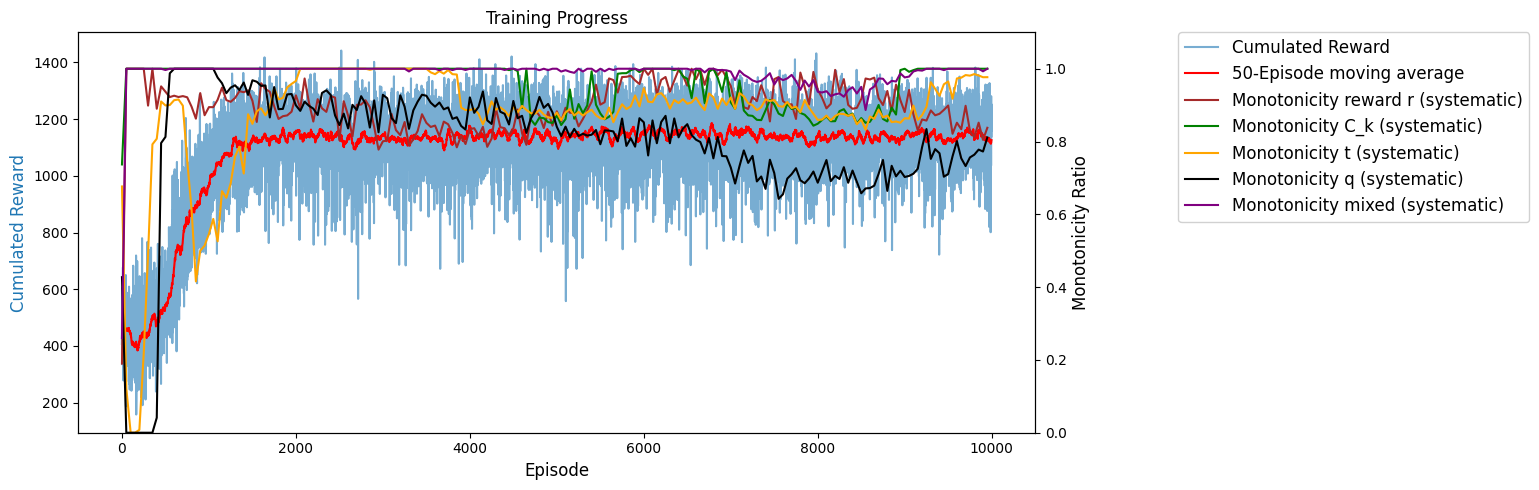

In [19]:
from training.plotting import plot_training_progress, plot_depth_epsilon

plot_training_progress(reward_history, monotonicity_violations)

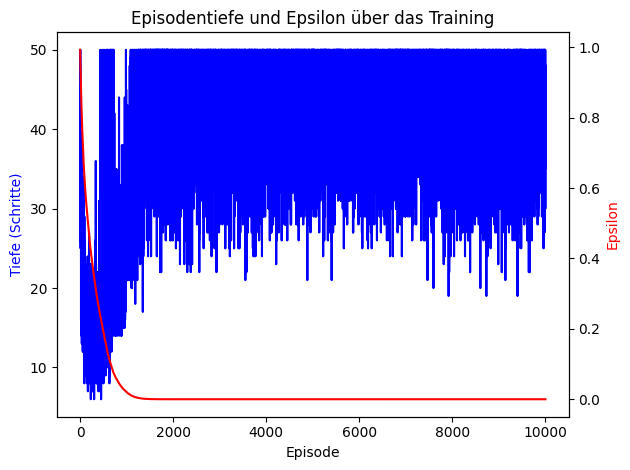

In [20]:
plot_depth_epsilon(depth_history)

## Beispiel-Durchlauf des trainierten Agenten

In [21]:
agent.epsilon = 0.0  # rein exploitativ, keine Exploration

obs, info = env.reset(show_instance = True)
done = False
total_reward = 0.0

while not done:
    action = agent.select_action(obs)
    print(f"Aktion gewählt: {action}")
    obs, reward, terminated, truncated, info = env.step(action)
    env.render()
    total_reward += reward
    done = terminated or truncated

print(f"\nGesamtreward (greedy Durchlauf): {total_reward:.2f}")

Geladene Instanz:
  Anfrage 1: [80, 1, 1, 1, 1, 0, 0, 0, 0]
  Anfrage 2: [55, 1, 2, 1, 3, 0, 0, 0, 0]
  Anfrage 3: [55, 1, 2, 1, 3, 0, 0, 0, 0]
  Anfrage 4: [9, 1, 1, 1, 3, 0, 0, 0, 0]
  Anfrage 5: [77, 1, 1, 1, 1, 0, 0, 0, 0]
  Anfrage 6: [54, 1, 1, 2, 1, 0, 0, 0, 0]
  Anfrage 7: [39, 2, 1, 2, 1, 0, 0, 0, 0]
  Anfrage 8: [69, 3, 1, 2, 1, 0, 0, 0, 0]
  Anfrage 9: [20, 3, 1, 1, 2, 0, 0, 0, 0]
  Anfrage 10: [77, 1, 1, 1, 1, 0, 0, 0, 0]
  Anfrage 11: [13, 2, 1, 2, 2, 0, 0, 0, 0]
  Anfrage 12: [9, 3, 2, 2, 1, 0, 0, 0, 0]
  Anfrage 13: [18, 1, 1, 1, 3, 0, 0, 0, 0]
  Anfrage 14: [70, 1, 1, 1, 1, 0, 0, 0, 0]
  Anfrage 15: [20, 2, 1, 2, 2, 0, 0, 0, 0]
  Anfrage 16: [62, 1, 1, 2, 1, 0, 0, 0, 0]
  Anfrage 17: [74, 1, 2, 1, 4, 0, 0, 0, 0]
  Anfrage 18: [25, 3, 3, 1, 1, 0, 0, 0, 0]
  Anfrage 19: [96, 1, 1, 1, 1, 0, 0, 0, 0]
  Anfrage 20: [8, 1, 3, 1, 1, 0, 0, 0, 0]
  Anfrage 21: [61, 1, 2, 1, 1, 0, 0, 0, 0]
  Anfrage 22: [63, 3, 1, 2, 1, 0, 0, 0, 0]
  Anfrage 23: [47, 1, 1, 2, 2, 0, 0, 0, 0]
  Anf

## Analyse der Reward-History

Diese Zelle berechnet einfache Kennzahlen (Mean, Std, Median, AUC, Final-Mean) aus der vorhandenen `reward_history`-Liste und zeigt einen Plot mit gleitendem Durchschnitt.

Episoden: 10000
Mean: 1087.0627, Std: 192.0980, Median: 1132.0000
Max: 1442.0000, Min: 158.0000


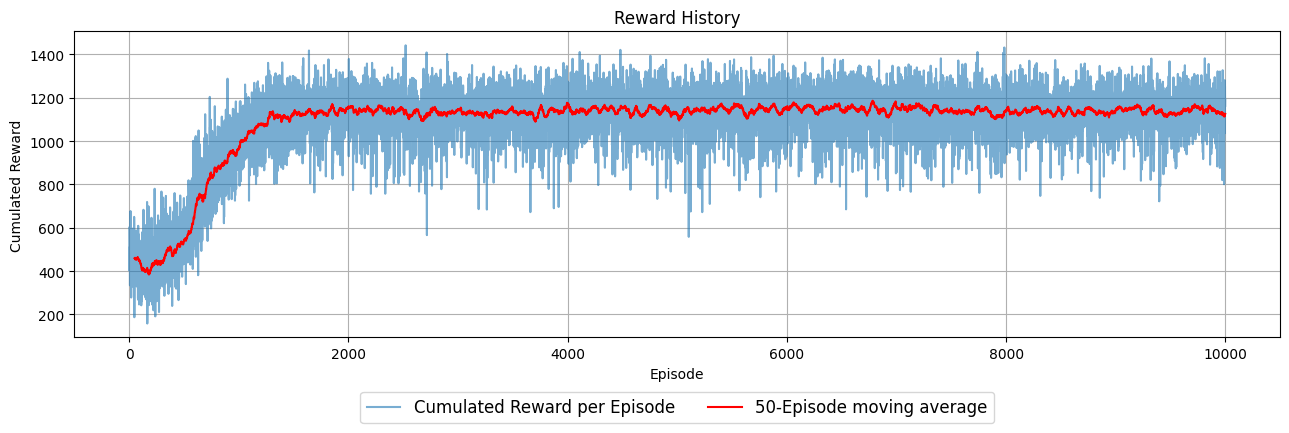

{'n': 10000,
 'mean': 1087.0627,
 'std': 192.09801803653093,
 'median': 1132.0,
 'max': 1442.0,
 'min': 158.0}

In [22]:
from training.plotting import plot_reward_moving_average
plot_reward_moving_average(reward_history, window=50)

## Evaluationsphase (eingefrorene Parameter, epsilon=0)

Nach abgeschlossenem Training werden die Netzgewichte fixiert (keine weiteren Trainingsschritte, `epsilon=0`, reines Exploitation) und für 10.000 Episoden evaluiert, um eine stabile Schätzung der Performance zu erhalten.

In [23]:
eval_rewards, eval_depths = agent.evaluate(num_episodes=1000)

[Eval] Episode   500/1000  Reward:  1210.00  Avg(500):  1152.44  Avg-Tiefe(500):   43.7
[Eval] Episode  1000/1000  Reward:  1262.00  Avg(500):  1159.37  Avg-Tiefe(500):   43.5


Eval-Episoden: 1000
Mean: 1155.9030, Std: 109.0792, Median: 1173.0000
Max: 1410.0000, Min: 630.0000


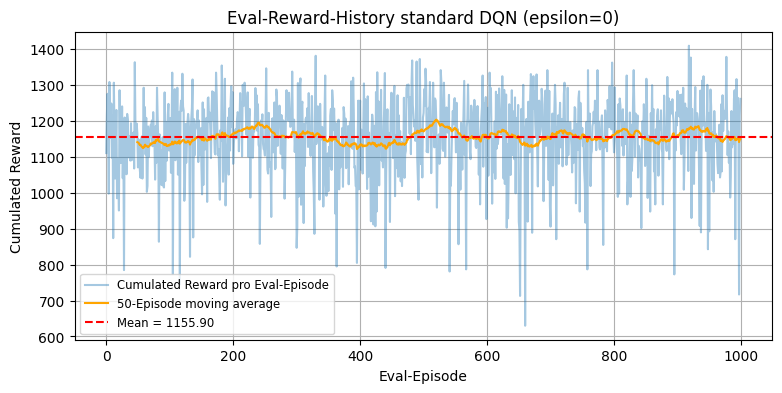

In [24]:
from training.plotting import plot_eval_rewards

eval_stats = plot_eval_rewards(eval_rewards, title="Eval-Reward-History standard DQN (epsilon=0)")